In [ ]:
!git clone https://github.com/manishgupta-ind/PV-Defect-Detection

In [ ]:
%cd PV-Defect-Detection
!ls


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

In [ ]:
df=pd.read_csv("data/Train/_annotations.csv")

In [ ]:
df.columns

Index(['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax',
       'Unnamed: 8'],
      dtype='object')

In [ ]:
df.shape

(11550, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11550 entries, 0 to 11549
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    11550 non-null  object 
 1   width       11550 non-null  int64  
 2   height      11550 non-null  int64  
 3   class       11550 non-null  object 
 4   xmin        11550 non-null  int64  
 5   ymin        11550 non-null  int64  
 6   xmax        11550 non-null  int64  
 7   ymax        11550 non-null  int64  
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(1), int64(6), object(2)
memory usage: 812.2+ KB


In [ ]:
df.isna().sum()

,0
filename,0
width,0
height,0
class,0
xmin,0
ymin,0
xmax,0
ymax,0
Unnamed: 8,11550


In [ ]:
import seaborn as sns



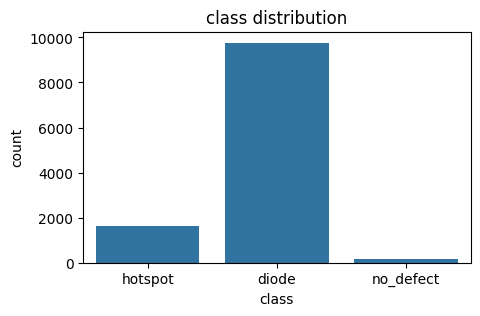

In [ ]:
plt.figure(figsize=(5, 3))
sns.countplot(x=df["class"])
plt.xlabel("class")
plt.ylabel("count")
plt.title("class distribution")
plt.show()

In [ ]:
data=df.copy()

In [ ]:
data_path="data/Train"

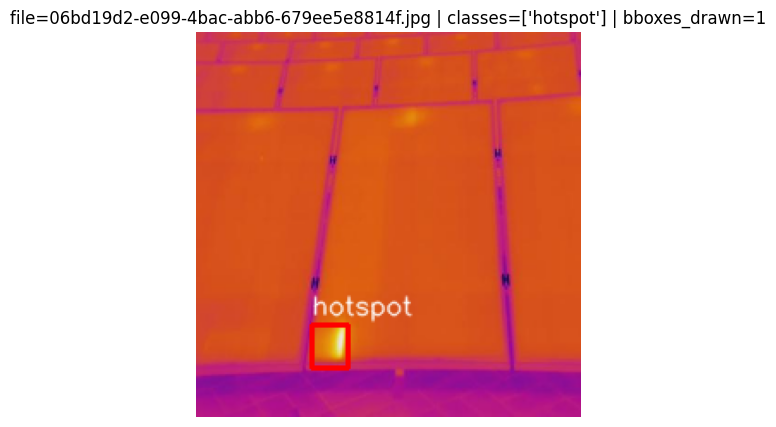

In [ ]:

import random

OUT_SIZE = 224
BBOX_COLS = ["xmin", "ymin", "xmax", "ymax"]
CLASS_COL = "class"

file_name = random.choice(data["filename"].unique().tolist())
rows = data[data["filename"] == file_name].copy()

image_path = os.path.join(data_path, file_name)

img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

img_resize = cv2.resize(img, (OUT_SIZE, OUT_SIZE), interpolation=cv2.INTER_LINEAR)
vis = img_resize.copy()

def valid_bbox(xmin, ymin, xmax, ymax):

    if xmin < 0 or ymin < 0 or xmax < 0 or ymax < 0:
        return False
    if xmax <= xmin or ymax <= ymin:
        return False
    return True


drawn = 0
for _, r in rows.iterrows():
    cls = str(r[CLASS_COL])

    xmin, ymin, xmax, ymax = r[BBOX_COLS]
    xmin, ymin, xmax, ymax = float(xmin), float(ymin), float(xmax), float(ymax)

    if not valid_bbox(xmin, ymin, xmax, ymax):
        continue


    xmin = max(0, min(xmin, w - 1))
    xmax = max(0, min(xmax, w - 1))
    ymin = max(0, min(ymin, h - 1))
    ymax = max(0, min(ymax, h - 1))


    if xmax < xmin: xmin, xmax = xmax, xmin
    if ymax < ymin: ymin, ymax = ymax, ymin


    scale_x = OUT_SIZE / w
    scale_y = OUT_SIZE / h

    x1 = int(round(xmin * scale_x))
    y1 = int(round(ymin * scale_y))
    x2 = int(round(xmax * scale_x))
    y2 = int(round(ymax * scale_y))


    vis = cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    vis = cv2.putText(
        vis, cls,
        (x1, max(0, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5,
        (255, 255, 255), 1, cv2.LINE_AA
    )
    drawn += 1


classes_in_image = rows[CLASS_COL].unique().tolist()
plt.figure(figsize=(5, 5))
plt.imshow(vis)
plt.title(f"file={file_name} | classes={classes_in_image} | bboxes_drawn={drawn}")
plt.axis("off")
plt.show()


In [ ]:
!pip install Ultralytics

In [ ]:
import os, shutil

CSV_PATH = "/content/PV-Defect-Detection/data/Train/_annotations.csv"
SRC_TRAIN = "/content/PV-Defect-Detection/data/Train"   # images folder
YOLO_DIR = "/content/PV-Defect-Detection/yolo_dataset"


data = pd.read_csv(CSV_PATH)


os.makedirs(f"{YOLO_DIR}/images/train", exist_ok=True)
os.makedirs(f"{YOLO_DIR}/labels/train", exist_ok=True)

labeled_files = set(df["filename"].dropna().astype(str))
train_files = [f for f in os.listdir(SRC_TRAIN) if f in labeled_files]

for f in train_files:
    shutil.copy2(os.path.join(SRC_TRAIN, f), f"{YOLO_DIR}/images/train/{f}")

print("Train images:", len(train_files))


class_map = {"hotspot": 0, "diode": 1}

def clamp(v, lo, hi):
    return max(lo, min(v, hi))

created, empty = 0, 0

for fname, g in df.groupby("filename"):
    img_path = f"{YOLO_DIR}/images/train/{fname}"
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    lines = []
    for _, r in g.iterrows():
        cls = str(r["class"])

        if cls not in class_map:
            continue

        xmin, ymin, xmax, ymax = float(r["xmin"]), float(r["ymin"]), float(r["xmax"]), float(r["ymax"])

        if xmin < 0 or ymin < 0 or xmax < 0 or ymax < 0:
            continue
        if xmax <= xmin or ymax <= ymin:
            continue

        xmin = clamp(xmin, 0, w - 1)
        xmax = clamp(xmax, 0, w - 1)
        ymin = clamp(ymin, 0, h - 1)
        ymax = clamp(ymax, 0, h - 1)

        x_c = ((xmin + xmax) / 2) / w
        y_c = ((ymin + ymax) / 2) / h
        bw  = (xmax - xmin) / w
        bh  = (ymax - ymin) / h

        lines.append(f"{class_map[cls]} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}")

    out_path = f"{YOLO_DIR}/labels/train/{os.path.splitext(fname)[0]}.txt"
    with open(out_path, "w") as f:
        f.write("\n".join(lines))

    created += 1
    if len(lines) == 0:
        empty += 1

print("label files written:", created)
print("empty labels (no bbox / no_defect):", empty)

Train images: 1011
label files written: 1011
empty labels (no bbox / no_defect): 162


In [ ]:
import random, glob

BASE = "/content/PV-Defect-Detection/yolo_dataset"

train_img_dir = f"{BASE}/images/train"
train_lbl_dir = f"{BASE}/labels/train"

val_img_dir = f"{BASE}/images/val"
val_lbl_dir = f"{BASE}/labels/val"

os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

images = glob.glob(train_img_dir + "/*.jpg")

random.seed(42)
random.shuffle(images)


val_count = int(len(images) * 0.2)
val_images = images[:val_count]

for img_path in val_images:
    filename = os.path.basename(img_path)
    name = os.path.splitext(filename)[0]

    label_path = f"{train_lbl_dir}/{name}.txt"


    shutil.move(img_path, f"{val_img_dir}/{filename}")


    if os.path.exists(label_path):
        shutil.move(label_path, f"{val_lbl_dir}/{name}.txt")

print("Validation images moved:", len(val_images))

Validation images moved: 161


In [ ]:
import glob, os

BASE = "/content/PV-Defect-Detection/yolo_dataset"

train_imgs = glob.glob(BASE + "/images/train/*")
train_lbls = glob.glob(BASE + "/labels/train/*.txt")
val_imgs   = glob.glob(BASE + "/images/val/*")
val_lbls   = glob.glob(BASE + "/labels/val/*.txt")

print("train images:", len(train_imgs))
print("train labels:", len(train_lbls))
print("val images:", len(val_imgs))
print("val labels:", len(val_lbls))

# check missing label files
missing_train = 0
for p in train_imgs:
    stem = os.path.splitext(os.path.basename(p))[0]
    if not os.path.exists(f"{BASE}/labels/train/{stem}.txt"):
        missing_train += 1

missing_val = 0
for p in val_imgs:
    stem = os.path.splitext(os.path.basename(p))[0]
    if not os.path.exists(f"{BASE}/labels/val/{stem}.txt"):
        missing_val += 1

print("missing train labels:", missing_train)
print("missing val labels:", missing_val)

train images: 648
train labels: 648
val images: 363
val labels: 363
missing train labels: 0
missing val labels: 0


In [ ]:
yaml_content = """\
path: /content/PV-Defect-Detection/yolo_dataset
train: images/train
val: images/val

names:
  0: hotspot
  1: diode
"""
with open("/content/PV-Defect-Detection/yolo_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print(open("/content/PV-Defect-Detection/yolo_dataset/data.yaml").read())

path: /content/PV-Defect-Detection/yolo_dataset
train: images/train
val: images/val

names:
  0: hotspot
  1: diode



In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data="/content/PV-Defect-Detection/yolo_dataset/data.yaml",
    epochs=50,
    batch=8,
    imgsz=416
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PV-Defect-Detection/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb7d8c8c6b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
!ls /content/PV-Defect-Detection/yolo_dataset/images
!ls /content/PV-Defect-Detection/yolo_dataset/labels

train  val
train  val


In [ ]:


TEST_BASE = "/content/PV-Defect-Detection/yolo_dataset"
test_imgs = glob.glob(TEST_BASE + "/images/test/*")
test_lbls = glob.glob(TEST_BASE + "/labels/test/*.txt")

print("test images:", len(test_imgs))
print("test labels:", len(test_lbls))

missing_lbl = []
for p in test_imgs:
    stem = os.path.splitext(os.path.basename(p))[0]
    if not os.path.exists(f"{TEST_BASE}/labels/test/{stem}.txt"):
        missing_lbl.append(p)

print("missing test labels:", len(missing_lbl))
print("example missing:", missing_lbl[:5])

test images: 0
test labels: 0
missing test labels: 0
example missing: []


In [ ]:
from ultralytics import YOLO

# load your trained model
model = YOLO('/content/drive/MyDrive/PV_YOLO_best.pt')

# run detection on test images
results = model.predict(
    source="/content/PV-Defect-Detection/data/Test",  # test images folder
    imgsz=416,
    conf=0.25,
    save=True
)


image 1/50 /content/PV-Defect-Detection/data/Test/0cfdc227-d016-4279-b8d1-b25d8ea95db1.jpg: 416x416 1 hotspot, 16.3ms
image 2/50 /content/PV-Defect-Detection/data/Test/0dc84bb7-a19d-4a33-9efa-030557b455d6.jpg: 416x416 (no detections), 10.9ms
image 3/50 /content/PV-Defect-Detection/data/Test/0fe80d23-d97c-4d47-8e29-648b896e331d.jpg: 416x416 2 hotspots, 12.9ms
image 4/50 /content/PV-Defect-Detection/data/Test/10f77190-e26a-4b7f-9eab-65b6fbe3546d.jpg: 416x416 215 diodes, 12.0ms
image 5/50 /content/PV-Defect-Detection/data/Test/1c52ccad-24f6-47c1-8d5f-17c06d133d32.jpg: 416x416 217 diodes, 10.8ms
image 6/50 /content/PV-Defect-Detection/data/Test/1e335257-76c0-41af-8d94-3ccff803322b.JPG: 352x416 (no detections), 10.1ms
image 7/50 /content/PV-Defect-Detection/data/Test/1f9ee72b-5622-4842-bb87-4c85e27a468f.jpg: 416x416 (no detections), 10.6ms
image 8/50 /content/PV-Defect-Detection/data/Test/2210b126-a74d-4db6-8340-a8c8f2700db3.jpg: 416x416 4 hotspots, 9.7ms
image 9/50 /content/PV-Defect-Dete

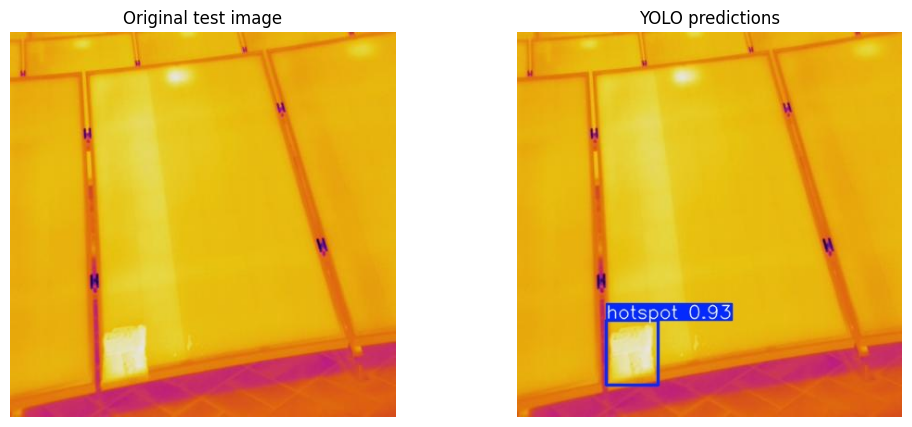

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

orig = "/content/PV-Defect-Detection/data/Test/0cfdc227-d016-4279-b8d1-b25d8ea95db1.jpg"
pred = "/content/PV-Defect-Detection/runs/detect/predict2/0cfdc227-d016-4279-b8d1-b25d8ea95db1.jpg"

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(Image.open(orig))
plt.title("Original test image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Image.open(pred))
plt.title("YOLO predictions")
plt.axis("off")

plt.show()